# GloFAS reforecast trigger 2025
<!-- markdownlint-disable MD013 -->
Revising the Chad GloFAS trigger for 2025

In [4]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, FuncFormatter

from src.datasources import glofas

In [3]:
def calculate_one_group_rp(group, col_name: str = "q", ascending: bool = True):
    """Calculate the empirical RP for a single group.

    Parameters
    ----------
    group : pd.DataFrame
        The group for which to calculate the RP.
    col_name : str, optional
        The name of the column for which to calculate the RP, by default "q".
    ascending : bool, optional
        Whether to rank the column in ascending order, by default True.
        Should be False for cases where a high number is severe
        (e.g. precipitation for flooding), and True for cases where a low
        number is severe (e.g. precipitation for drought).

    Returns
    -------
    pd.DataFrame
        The input group with the RP columns added.
    """
    group[f"{col_name}_rank"] = group[col_name].rank(ascending=ascending)
    group[f"{col_name}_rp"] = (len(group) + 1) / group[f"{col_name}_rank"]
    return group

## Load and process data

### Reanalysis

In [4]:
df_rea = glofas.load_reanalysis().rename(columns={"time": "valid_time"})

In [5]:
rp_a = 4

In [6]:
df_rea_yearly = (
    df_rea.groupby(df_rea["valid_time"].dt.year)["dis24"].max().reset_index()
)

In [7]:
df_rea_yearly = calculate_one_group_rp(
    df_rea_yearly, col_name="dis24", ascending=False
)

In [8]:
df_rea_yearly = df_rea_yearly.sort_values("dis24")

In [9]:
df_rea_yearly

,valid_time,dis24,dis24_rank,dis24_rp
18,2021,1138.0391,21.0,1.047619
6,2009,1495.7578,20.0,1.100000
14,2017,1701.5703,19.0,1.157895
5,2008,1808.2734,18.0,1.222222
20,2023,1827.8008,17.0,1.294118
12,2015,1913.9453,16.0,1.375000
11,2014,2316.0469,15.0,1.466667
1,2004,2338.4140,14.0,1.571429
10,2013,2339.5469,13.0,1.692308
8,2011,2377.5781,12.0,1.833333


Get the level that corresponds to a 4-yr RP in the reanalysis

In [10]:
thresh_a = np.interp(rp_a, df_rea_yearly["dis24_rp"], df_rea_yearly["dis24"])

In [11]:
thresh_a

4096.536209090909

Get the first date each year that the reanalysis met its 4-yr RP

In [12]:
df_rea_startdates = (
    (
        df_rea[df_rea["dis24"] >= thresh_a]
        .groupby(df_rea["valid_time"].dt.year)["valid_time"]
        .min()
    )
    .rename("min_date")
    .reset_index()
)
df_rea_startdates["year"] = df_rea_startdates["valid_time"]
df_rea_startdates

,valid_time,min_date,year
0,2003,2003-08-31,2003
1,2005,2005-09-26,2005
2,2010,2010-09-05,2010
3,2012,2012-08-27,2012
4,2022,2022-09-13,2022


In [13]:
df_rea_yearly = df_rea_yearly.merge(df_rea_startdates, how="left")

In [14]:
df_rea_yearly

,valid_time,dis24,dis24_rank,dis24_rp,min_date,year
0,2021,1138.0391,21.0,1.047619,NaT,NaN
1,2009,1495.7578,20.0,1.100000,NaT,NaN
2,2017,1701.5703,19.0,1.157895,NaT,NaN
3,2008,1808.2734,18.0,1.222222,NaT,NaN
4,2023,1827.8008,17.0,1.294118,NaT,NaN
5,2015,1913.9453,16.0,1.375000,NaT,NaN
6,2014,2316.0469,15.0,1.466667,NaT,NaN
7,2004,2338.4140,14.0,1.571429,NaT,NaN
8,2013,2339.5469,13.0,1.692308,NaT,NaN
9,2011,2377.5781,12.0,1.833333,NaT,NaN


Get the reanalysis triggered years - these will be what we are trying to target

In [15]:
df_rea_yearly["trig"] = df_rea_yearly["dis24_rp"] >= rp_a

In [16]:
df_rea_yearly[df_rea_yearly["trig"]]

,valid_time,dis24,dis24_rank,dis24_rp,min_date,year,trig
16,2005,4930.1953,5.0,4.400000,2005-09-26,2005.0,True
17,2012,5551.9844,4.0,5.500000,2012-08-27,2012.0,True
18,2003,6072.0000,3.0,7.333333,2003-08-31,2003.0,True
19,2022,6254.0547,2.0,11.000000,2022-09-13,2022.0,True
20,2010,6714.9453,1.0,22.000000,2010-09-05,2010.0,True


In [17]:
target_years = df_rea_yearly[df_rea_yearly["trig"]]["valid_time"].to_list()

In [18]:
target_years

[2005, 2012, 2003, 2022, 2010]

## Reforecast

In [19]:
df_ref_ens = glofas.load_reforecast_ensembles()
df_ref_ens = df_ref_ens.rename(columns={"time": "issued_time"})

In [20]:
df_ref_ens_mean = (
    df_ref_ens.groupby(["issued_time", "valid_time", "leadtime"])["dis24"]
    .mean()
    .reset_index()
)

In [21]:
df_ref_ens_mean

,issued_time,valid_time,leadtime,dis24
0,2003-06-01,2003-06-02,1,177.359375
1,2003-06-01,2003-06-03,2,175.403122
2,2003-06-01,2003-06-04,3,173.890625
3,2003-06-01,2003-06-05,4,173.784378
4,2003-06-01,2003-06-06,5,172.512497
...,...,...,...,...
70805,2023-11-25,2024-01-05,41,82.784378
70806,2023-11-25,2024-01-06,42,81.103127
70807,2023-11-25,2024-01-07,43,79.421875
70808,2023-11-25,2024-01-08,44,77.722656


### Merge reanalysis and reforecast

In [22]:
df_daily = df_ref_ens_mean.merge(
    df_rea, on="valid_time", suffixes=("_f", "_a")
)

In [23]:
df_daily

,issued_time,valid_time,leadtime,dis24_f,dis24_a
0,2003-06-01,2003-06-02,1,177.359375,174.31250
1,2003-06-01,2003-06-03,2,175.403122,173.75000
2,2003-06-01,2003-06-04,3,173.890625,172.31250
3,2003-06-01,2003-06-05,4,173.784378,170.56250
4,2003-06-01,2003-06-06,5,172.512497,169.31250
...,...,...,...,...,...
70789,2023-11-25,2023-12-27,32,100.818748,96.18750
70790,2023-11-25,2023-12-28,33,98.386719,93.85156
70791,2023-11-25,2023-12-29,34,96.084373,91.66406
70792,2023-11-25,2023-12-30,35,93.896873,89.58594


In [24]:
df_daily["bias"] = df_daily["dis24_f"] / df_daily["dis24_a"]

<Axes: xlabel='leadtime'>

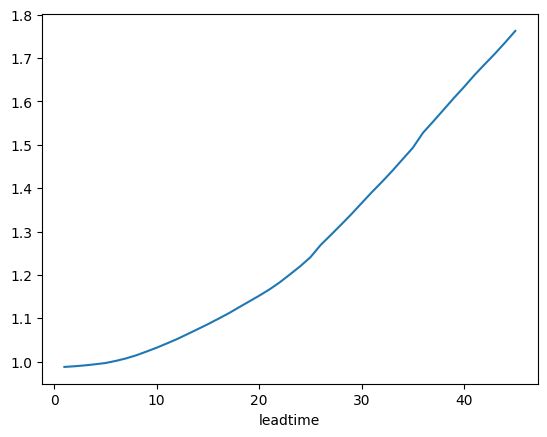

In [25]:
df_daily.groupby("leadtime")["bias"].mean().plot()

This is pretty significant leadtime bias, which we've noted before and mentioned to GloFAS. This also means that if we use a fixed threshold, we will be more likely to trigger on the longer leadtimes than on the short ones (which is convenient).

In [26]:
df_yearly = (
    df_daily.groupby([df_daily["valid_time"].dt.year, "leadtime"])[
        ["dis24_f", "dis24_a"]
    ]
    .max()
    .reset_index()
)

In [27]:
lts = df_daily["leadtime"].unique()

Set the reforecast RP to the reanalysis RP (both 4 years)

In [28]:
rp_f = rp_a

In [29]:
total_years = len(df_rea_yearly)

## Iterate over leadtimes

Here we iterate over all the maximum/minimum leadtime contraints to see what the performance looks like. We probably don't need to worry too much about the minimum leadtime, since because of the bias we will tend to trigger on the longer leadtimes. But we can include it anyways for completeness.

In [30]:
p = len(target_years)
n = total_years - p


dicts = []
for lt_min in lts:
    for lt_max in lts:
        if lt_max < lt_min:
            continue
        dff = df_yearly[
            (df_yearly["leadtime"] >= lt_min)
            & (df_yearly["leadtime"] <= lt_max)
        ]
        dff_max = (
            dff.groupby("valid_time")[["dis24_f", "dis24_a"]]
            .max()
            .reset_index()
        )
        dff_max = calculate_one_group_rp(
            dff_max, col_name="dis24_f", ascending=False
        )
        dff_max["trig"] = dff_max["dis24_f_rp"] >= rp_f
        trig_years = dff_max[dff_max["trig"]]["valid_time"].to_list()

        pp = len(trig_years)
        pn = total_years - pp
        tp = sum([x in target_years for x in trig_years])
        fn = p - tp
        tn = pn - fn
        fp = n - tn

        corr = dff_max[["dis24_f", "dis24_a"]].corr().loc["dis24_f", "dis24_a"]

        dicts.append(
            {
                "lt_min": lt_min,
                "lt_max": lt_max,
                "tp": tp,
                "fn": fn,
                "tn": tn,
                "fp": fp,
                "corr": corr,
            }
        )

In [31]:
df_metrics = pd.DataFrame(dicts)

Calculate the standard accuracy metrics

In [32]:
df_metrics["tpr"] = df_metrics["tp"] / p
df_metrics["ppv"] = df_metrics["tp"] / pp
df_metrics["fpr"] = df_metrics["fp"] / n

### Plot accuracy metrics

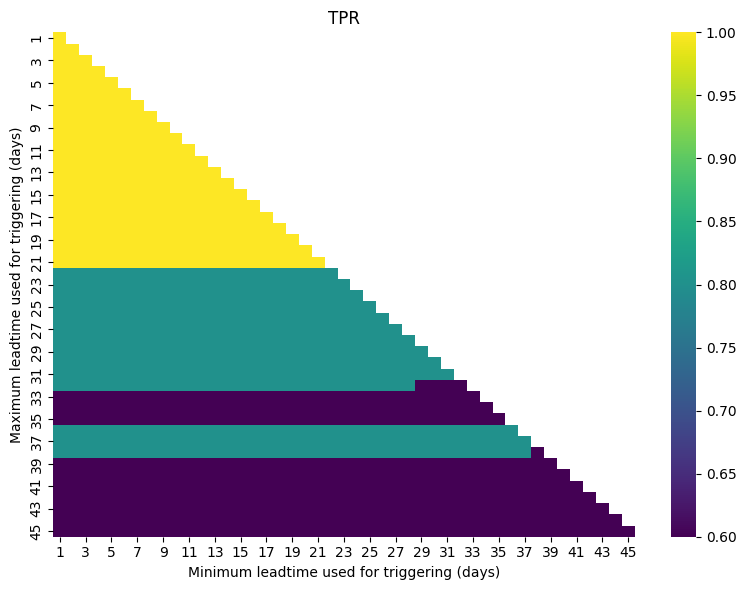

In [33]:
heatmap_data = df_metrics.pivot(index="lt_max", columns="lt_min", values="tpr")

# Create the heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap_data, cmap="viridis", ax=ax)

# Set axis labels
ax.set_xlabel("lt_min")
ax.set_ylabel("lt_max")
ax.set_title("TPR")

ax.set_xlabel("Minimum leadtime used for triggering (days)")
ax.set_ylabel("Maximum leadtime used for triggering (days)")

plt.tight_layout()
plt.show()

Here we see that we get a TPR of 100% whenever we limit ourselves to a leadtime of 21 days. As expected the minimum leadtime doesn't really matter. Note that because we have the same number of trigger years and target years, the PPV and F1 will equal the TPR so we only need to plot one.

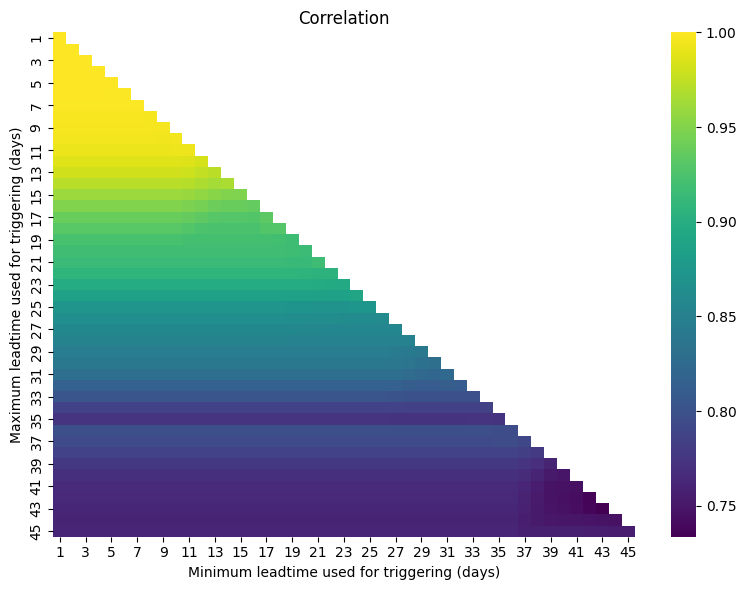

In [34]:
heatmap_data = df_metrics.pivot(
    index="lt_max", columns="lt_min", values="corr"
)

# Create the heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap_data, cmap="viridis", ax=ax, vmax=1)

# Set axis labels
ax.set_xlabel("lt_min")
ax.set_ylabel("lt_max")
ax.set_title("Correlation")

ax.set_xlabel("Minimum leadtime used for triggering (days)")
ax.set_ylabel("Maximum leadtime used for triggering (days)")

plt.tight_layout()
plt.show()

To get a bit more nuance we can also look at the correlation. As expected it's quite good for short leadtimes, but seems like it drops off a bit around 12 days.

Anyways, we can now limit ourselves to the maximum leadtime that still gives a TPR of 100% (true, the slightly lower TPR out at the leadtimes in the 20s and 30s is not that bad, but 21 days of leadtime is already plenty).

In [35]:
lt_ceiling = df_metrics[df_metrics["tpr"] == 1]["lt_max"].max()

In [36]:
lt_ceiling

21

## Further refine leadtimes

With this leadtime ceiling in mind, we can looks more closely at how the correlation compares with the effective leadtime (i.e. the actual number of days between the first issued forecast that surpasses its 4-yr threshold, and the day the reanalysis crosses its 4-yr threshold). As before we have to define the thresholds dynamically.

In [37]:
dicts = []
for lt_max in range(1, lt_ceiling + 1):
    dff = df_yearly[df_yearly["leadtime"] <= lt_max]
    dff_max = (
        dff.groupby("valid_time")[["dis24_f", "dis24_a"]].max().reset_index()
    )
    dff_max = calculate_one_group_rp(
        dff_max, col_name="dis24_f", ascending=False
    )
    dff_max = dff_max.sort_values("dis24_f")
    corr = dff_max[["dis24_f", "dis24_a"]].corr().loc["dis24_f", "dis24_a"]
    thresh_f = np.interp(rp_f, dff_max["dis24_f_rp"], dff_max["dis24_f"])
    dff_daily = df_daily[
        (df_daily["leadtime"] <= lt_max) & (df_daily["dis24_f"] >= thresh_f)
    ]
    df_trig_dates = dff_daily.loc[
        dff_daily.groupby(dff_daily["valid_time"].dt.year)[
            "issued_time"
        ].idxmin()
    ]
    df_trig_dates["year"] = df_trig_dates["issued_time"].dt.year
    df_trig_dates = df_trig_dates.merge(
        df_rea_startdates[["year", "min_date"]]
    )
    df_trig_dates["lt_actual"] = (
        df_trig_dates["min_date"] - df_trig_dates["issued_time"]
    ).dt.days
    lt_avg = df_trig_dates["lt_actual"].mean()
    dicts.append(
        {
            "lt_max": lt_max,
            "corr": corr,
            "lt_avg": lt_avg,
            "thresh_f": thresh_f,
        }
    )

In [38]:
df_metrics_refined = pd.DataFrame(dicts)

### Plot action trigger leadtime options

[None, None]

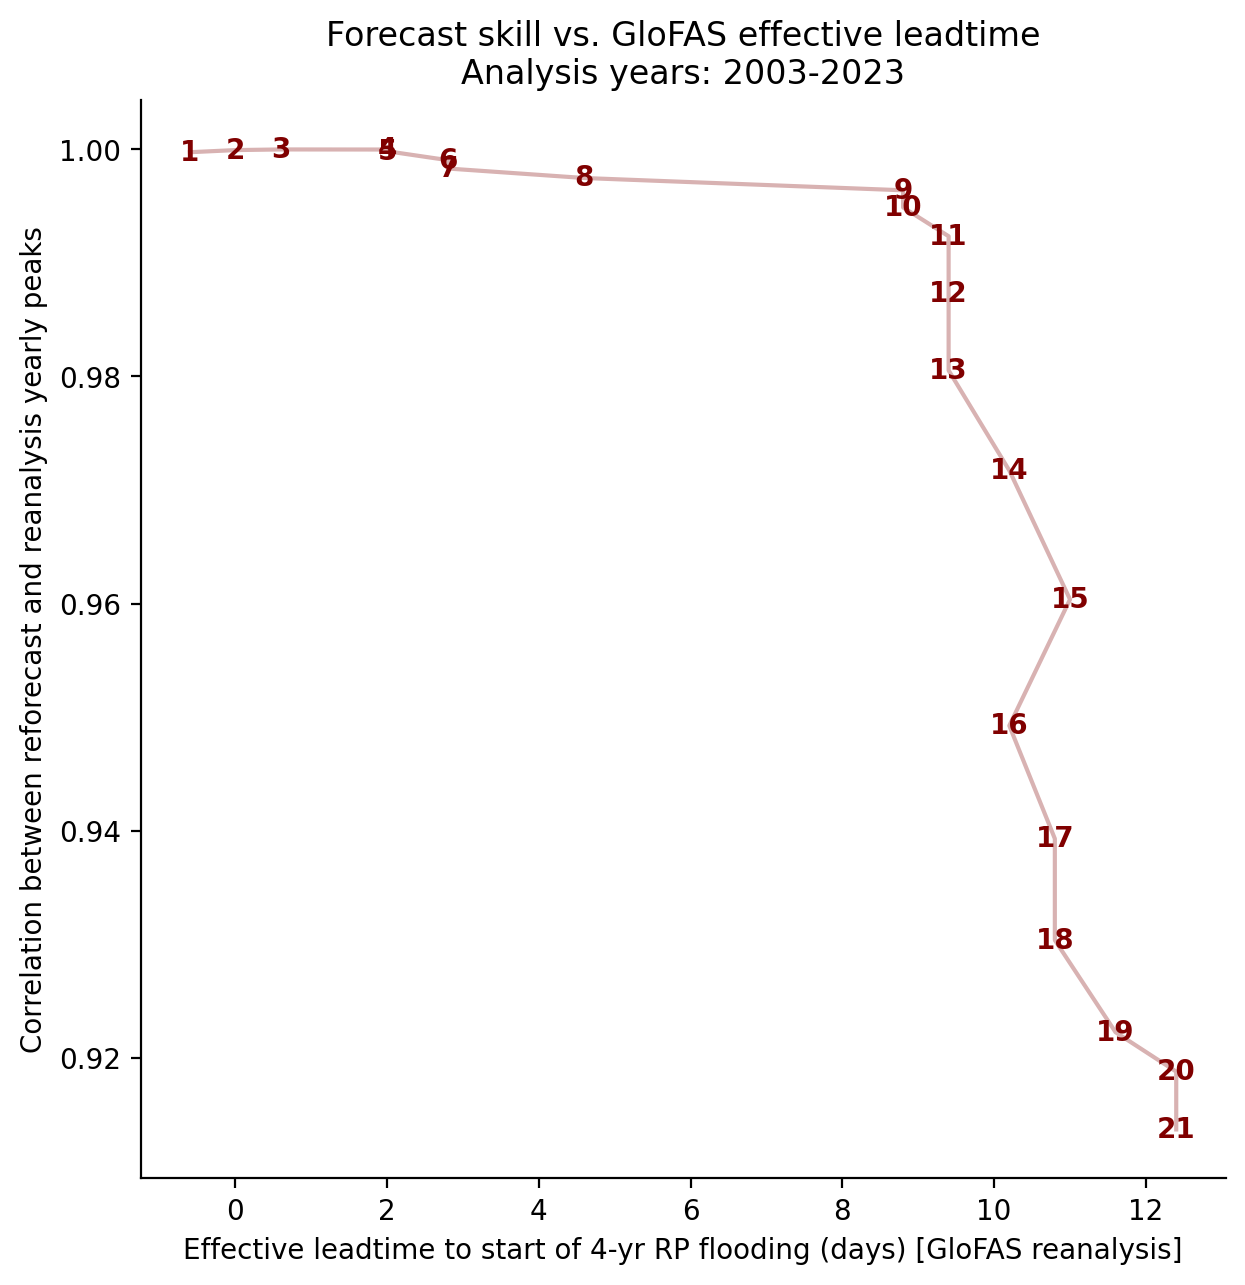

In [39]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=200)
color = "maroon"
df_metrics_refined.plot(
    x="lt_avg", y="corr", ax=ax, legend=False, alpha=0.3, color=color
)

for lt_max, row in df_metrics_refined.set_index("lt_max").iterrows():
    ax.annotate(
        lt_max,
        row[["lt_avg", "corr"]],
        color=color,
        va="center",
        ha="center",
        fontweight="bold",
    )

ax.set_xlabel(
    f"Effective leadtime to start of {rp_a}-yr RP flooding (days) [GloFAS reanalysis]"
)
ax.set_ylabel("Correlation between reforecast and reanalysis yearly peaks")
ax.set_title(
    "Forecast skill vs. GloFAS effective leadtime\n"
    f"Analysis years: {df_yearly['valid_time'].min()}-{df_yearly['valid_time'].max()}"
)

[ax.spines[x].set_visible(False) for x in ["top", "right"]]

Interesting- here we see the correlation drop off a bit above 11 days of leadtime. So we can stick with 10 days leadtime as the action threshold, since this is what it was set to before.

In [40]:
selected_max_lt = 10
selected_thresh_f = df_metrics_refined.set_index("lt_max").loc[
    selected_max_lt, "thresh_f"
]

### Plot readiness trigger leadtime options

Then using this threshold, we can see how things look when we apply it to longer leadtimes for a readiness trigger. We expect the RP to go down, because of forecast variability and of course the leadtime bias. We are just sticking with this same threshold for simplicity (the previous trigger had the same threshold for action and readiness which was nice).

In [41]:
dicts = []
for lt_max in range(selected_max_lt, lt_ceiling + 1):
    dff = df_yearly[df_yearly["leadtime"] <= lt_max]
    dff_max = (
        dff.groupby("valid_time")[["dis24_f", "dis24_a"]].max().reset_index()
    )
    dff_max = calculate_one_group_rp(
        dff_max, col_name="dis24_f", ascending=False
    )
    dff_max = dff_max.sort_values("dis24_f")
    dff_daily = df_daily[
        (df_daily["leadtime"] <= lt_max)
        & (df_daily["dis24_f"] >= selected_thresh_f)
    ]
    df_trig_dates = dff_daily.loc[
        dff_daily.groupby(dff_daily["valid_time"].dt.year)[
            "issued_time"
        ].idxmin()
    ]
    df_trig_dates["year"] = df_trig_dates["issued_time"].dt.year
    df_trig_dates = df_trig_dates.merge(
        df_rea_startdates[["year", "min_date"]]
    )
    df_trig_dates["lt_actual"] = (
        df_trig_dates["min_date"] - df_trig_dates["issued_time"]
    ).dt.days
    lt_avg = df_trig_dates["lt_actual"].mean()

    rp = np.interp(
        selected_thresh_f, dff_max["dis24_f"], dff_max["dis24_f_rp"]
    )
    dicts.append({"lt_max": lt_max, "rp": rp, "lt_avg": lt_avg})

In [42]:
df_metric_readiness = pd.DataFrame(dicts)

In [43]:
df_metric_readiness

,lt_max,rp,lt_avg
0,10,4.000000,8.8
1,11,3.967803,11.4
2,12,3.884535,11.4
3,13,3.725351,16.4
4,14,2.996872,17.2
5,15,2.734566,17.2
6,16,2.564699,18.0
7,17,2.306389,20.8
8,18,1.995110,21.4
9,19,1.944790,22.4


[None, None]

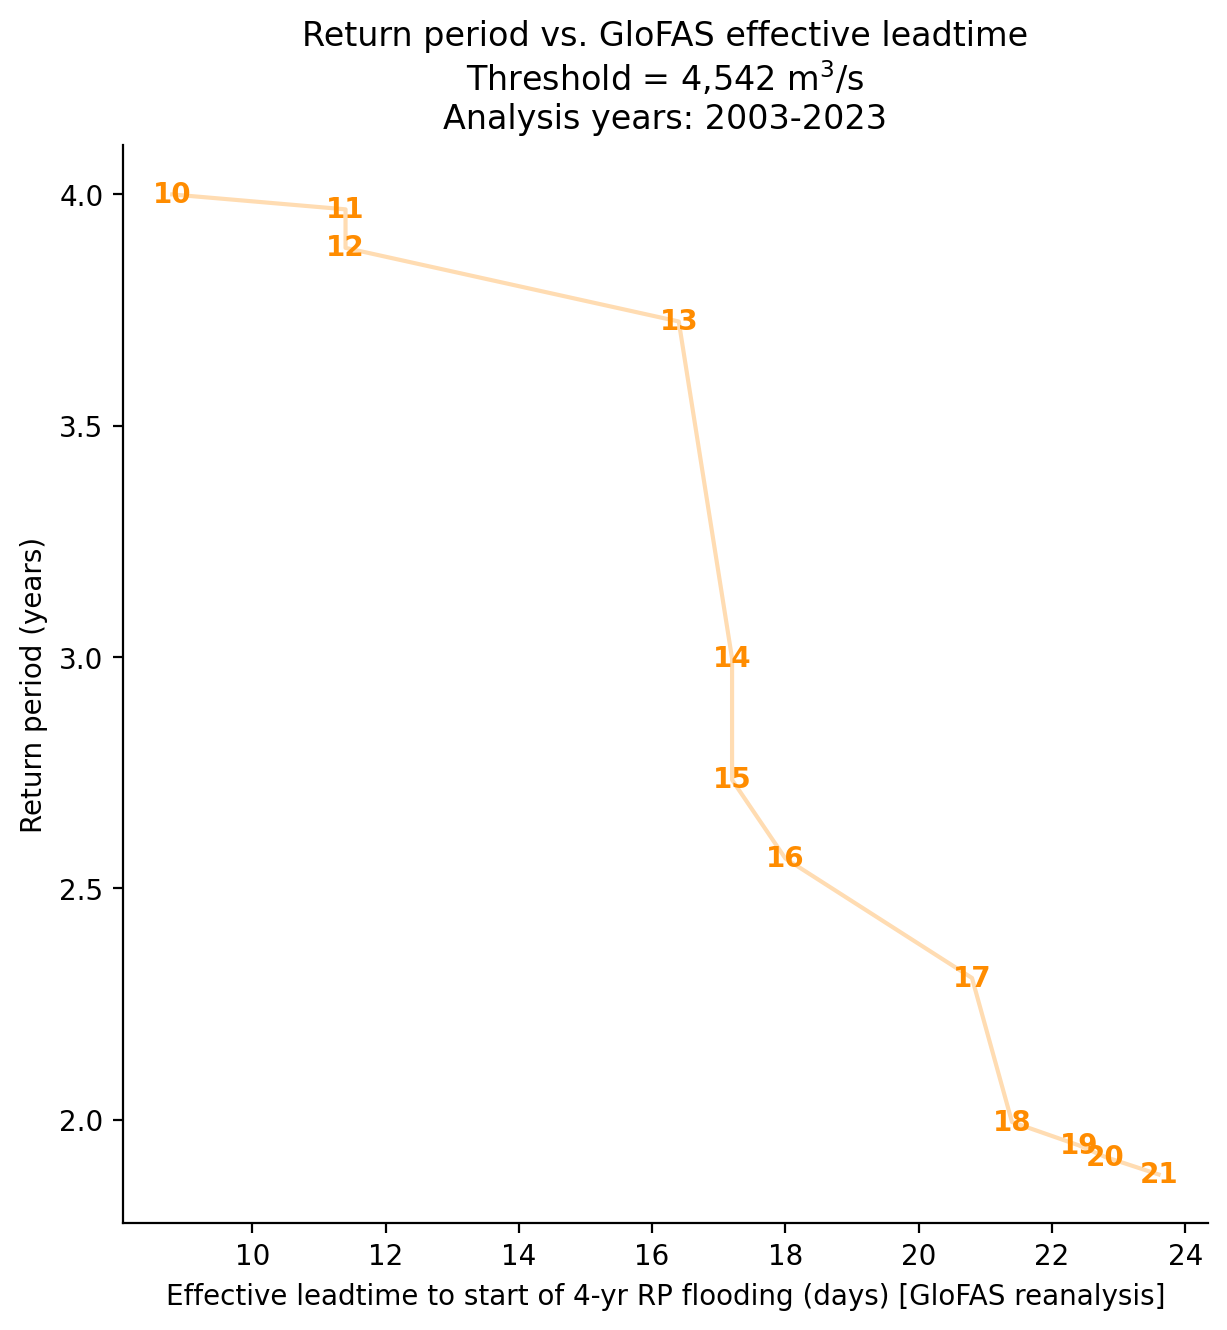

In [44]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=200)
color = "darkorange"
df_metric_readiness.plot(
    x="lt_avg", y="rp", ax=ax, legend=False, alpha=0.3, color=color
)

for lt_max, row in df_metric_readiness.set_index("lt_max").iterrows():
    ax.annotate(
        lt_max,
        row[["lt_avg", "rp"]],
        color=color,
        va="center",
        ha="center",
        fontweight="bold",
    )

ax.set_xlabel(
    f"Effective leadtime to start of {rp_a}-yr RP flooding (days) [GloFAS reanalysis]"
)
ax.set_ylabel("Return period (years)")
ax.set_title(
    "Return period vs. GloFAS effective leadtime\n"
    f"Threshold = {selected_thresh_f:,.0f} m$^3$/s\n"
    f"Analysis years: {df_yearly['valid_time'].min()}-{df_yearly['valid_time'].max()}"
)

[ax.spines[x].set_visible(False) for x in ["top", "right"]]

This plot looks more or less as expected. The return period drops as we include more leadtimes. We can then just pick the one that stays within the CERF requirement of 3-yr RP, which is 14 days. (The old readiness leadtime was 15 days, so good that we're close)

In [45]:
selected_lt_max_readiness = 14

We can then just double check that these thresholds are correct, based on the daily data. We expect 5 trigger years for action and 7 for readiness.

In [46]:
df_ref_ens_mean[
    (df_ref_ens_mean["dis24"] >= selected_thresh_f)
    & (df_ref_ens_mean["leadtime"] <= selected_max_lt)
]["valid_time"].dt.year.unique()

array([2003, 2005, 2010, 2012, 2022], dtype=int32)

In [47]:
df_ref_ens_mean[
    (df_ref_ens_mean["dis24"] >= selected_thresh_f)
    & (df_ref_ens_mean["leadtime"] <= selected_lt_max_readiness)
]["valid_time"].dt.year.unique()

array([2003, 2005, 2007, 2010, 2012, 2018, 2022], dtype=int32)

## Plot peformance

In [48]:
df_daily

,issued_time,valid_time,leadtime,dis24_f,dis24_a,bias
0,2003-06-01,2003-06-02,1,177.359375,174.31250,1.017479
1,2003-06-01,2003-06-03,2,175.403122,173.75000,1.009514
2,2003-06-01,2003-06-04,3,173.890625,172.31250,1.009159
3,2003-06-01,2003-06-05,4,173.784378,170.56250,1.018890
4,2003-06-01,2003-06-06,5,172.512497,169.31250,1.018900
...,...,...,...,...,...,...
70789,2023-11-25,2023-12-27,32,100.818748,96.18750,1.048148
70790,2023-11-25,2023-12-28,33,98.386719,93.85156,1.048323
70791,2023-11-25,2023-12-29,34,96.084373,91.66406,1.048223
70792,2023-11-25,2023-12-30,35,93.896873,89.58594,1.048121


In [6]:
max_days = 10
[str(24 * x) for x in range(1, max_days + 1)]

['24', '48', '72', '96', '120', '144', '168', '192', '216', '240']

In [49]:
xcol, ycol = [f"dis24_{x}" for x in ["f", "a"]]

xmax, ymax = (
    df_daily[df_daily["leadtime"] <= selected_lt_max_readiness][
        [xcol, ycol]
    ].max()
    * 1.1
)

In [50]:
def plot_trigger_years(trig_name, lang="EN"):
    if lang not in ["EN", "FR"]:
        raise ValueError("lang must be EN or FR")
    lt_max = (
        selected_max_lt if trig_name == "action" else selected_lt_max_readiness
    )
    trig_color = "maroon" if trig_name == "action" else "darkorange"
    a_color = "dodgerblue"
    xcol, ycol = [f"dis24_{x}" for x in ["f", "a"]]

    fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

    df_plot = (
        df_daily[df_daily["leadtime"] <= lt_max]
        .groupby(df_daily["valid_time"].dt.year)[[xcol, ycol]]
        .max()
        .reset_index()
    )

    df_plot = calculate_one_group_rp(
        df_plot, col_name=xcol, ascending=False
    ).sort_values(xcol)
    rp = np.interp(selected_thresh_f, df_plot[xcol], df_plot[f"{xcol}_rp"])

    for year, row in df_plot.set_index("valid_time").iterrows():
        if row[xcol] >= selected_thresh_f:
            color = trig_color
            fontweight = "bold"
        else:
            color = "grey"
            fontweight = "normal"
        ax.annotate(
            year,
            row[[xcol, ycol]],
            ha="center",
            va="center",
            color=color,
            fontweight=fontweight,
        )

    thresh_str = "Threshold" if lang == "EN" else "Seuil "
    ax.axvline(selected_thresh_f, color=trig_color)
    ax.axvspan(selected_thresh_f, xmax, facecolor=trig_color, alpha=0.1)
    ax.annotate(
        f" {thresh_str}: {selected_thresh_f:,.0f} m$^3$/s".replace(
            ",", " " if lang == "FR" else ","
        ),
        (selected_thresh_f, 0),
        rotation=90,
        ha="right",
        va="bottom",
        fontstyle="italic",
        color=trig_color,
    )

    ax.axhline(thresh_a, color=a_color)
    ax.axhspan(thresh_a, ymax, facecolor=a_color, alpha=0.1)
    ax.annotate(
        (
            " 4-yr RP level"
            if lang == "EN"
            else " niveau période de retour 4-ans"
        ),
        (0, thresh_a),
        ha="left",
        va="bottom",
        fontstyle="italic",
        color=a_color,
    )

    ax.set_xlim((0, xmax))
    ax.set_ylim((0, ymax))

    ax.set_xlabel(
        "Maximum forecasted value (m$^3$/s) [GloFAS reforecast]"
        if lang == "EN"
        else "Valeur maximum prévue (m$^3$/s) [re-prévision GloFAS]"
    )
    ax.set_ylabel(
        "Maximum reanalysis value (m$^3$/s) [GloFAS reanalysis]"
        if lang == "EN"
        else "Valeur maximum de réanalyse (m$^3$/s) [réanalyse GloFAS]"
    )
    if lang == "FR":
        if trig_name == "readiness":
            trig_name_str = "de mobilisation"
        else:
            trig_name_str = "d'action"
    else:
        trig_name_str = trig_name
    ax.set_title(
        f"{trig_name_str.capitalize()} trigger historical performance\n"
        f"Maximum leadtime: {lt_max} days\n"
        f"Return period: {rp:.1f} years"
        if lang == "EN"
        else f"Performance historique de déclencheur {trig_name_str}\n"
        f"Délai maximum : {lt_max} jours\n"
        f"Période de retour : {rp:.1f} ans".replace(".", ",")
    )

    def french_thousands(x, _):
        return f"{int(x):,}".replace(",", " ")

    if lang == "EN":
        formatter = StrMethodFormatter("{x:,.0f}")
    else:
        formatter = FuncFormatter(french_thousands)

    ax.yaxis.set_major_formatter(formatter)
    ax.xaxis.set_major_formatter(formatter)

    [ax.spines[x].set_visible(False) for x in ["top", "right"]]
    return fig, ax

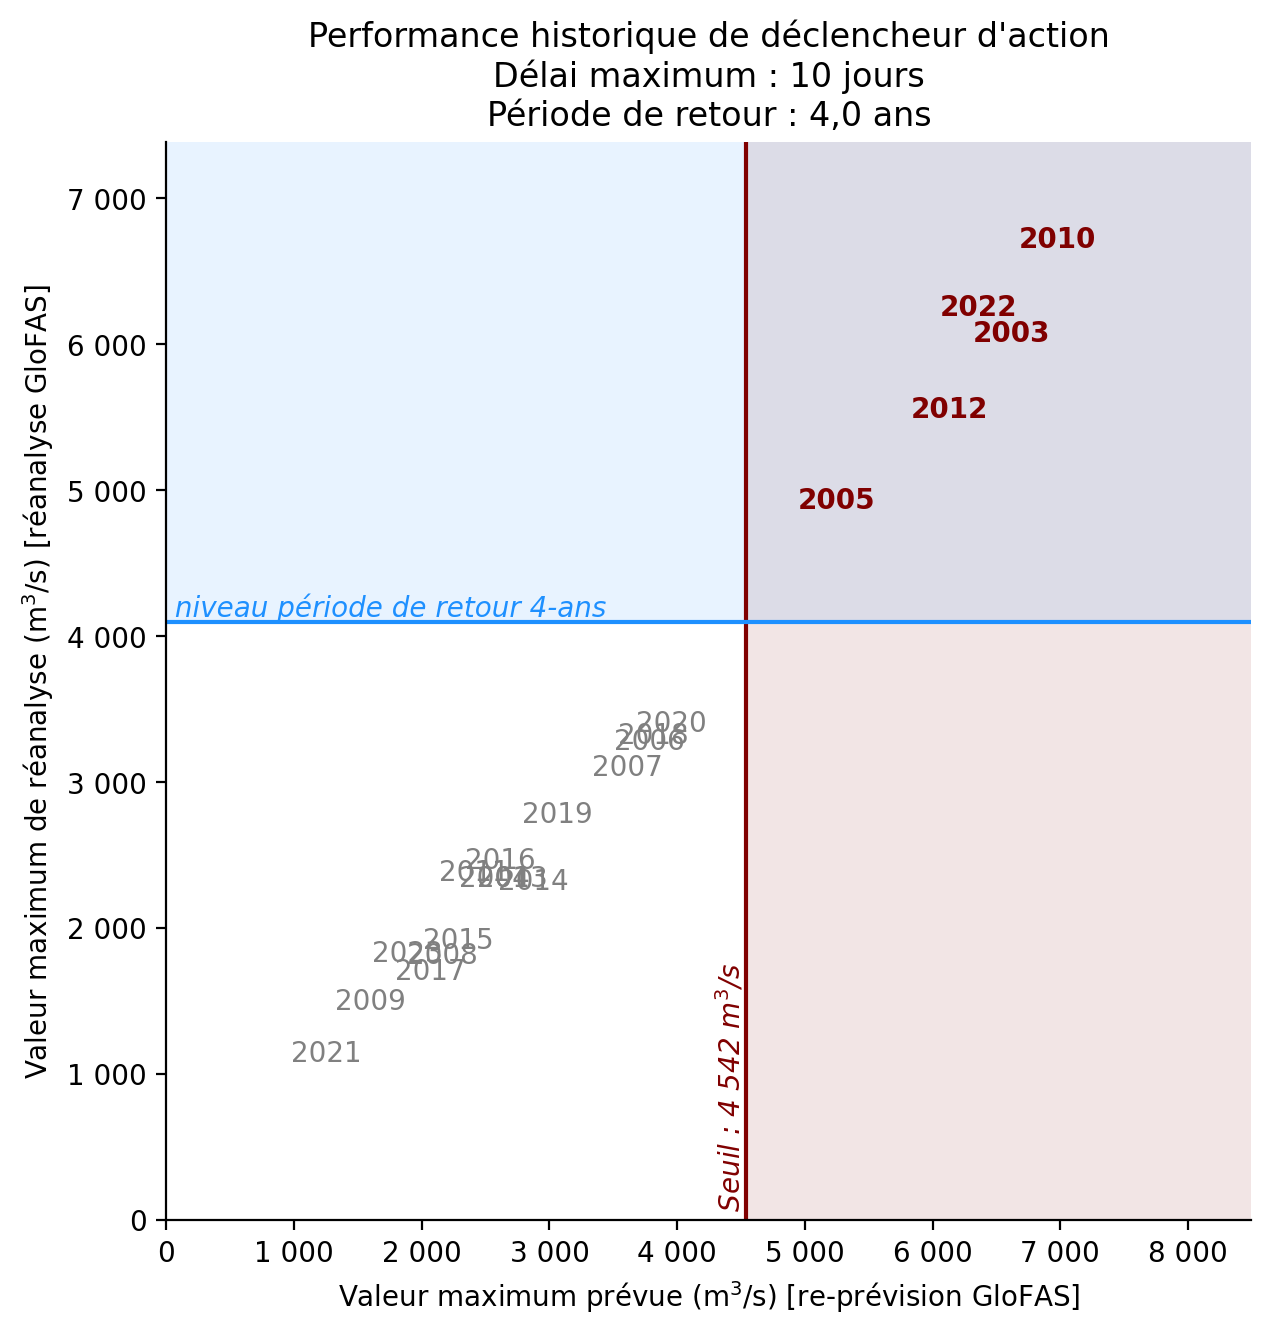

In [51]:
fig, ax = plot_trigger_years("action", lang="FR")

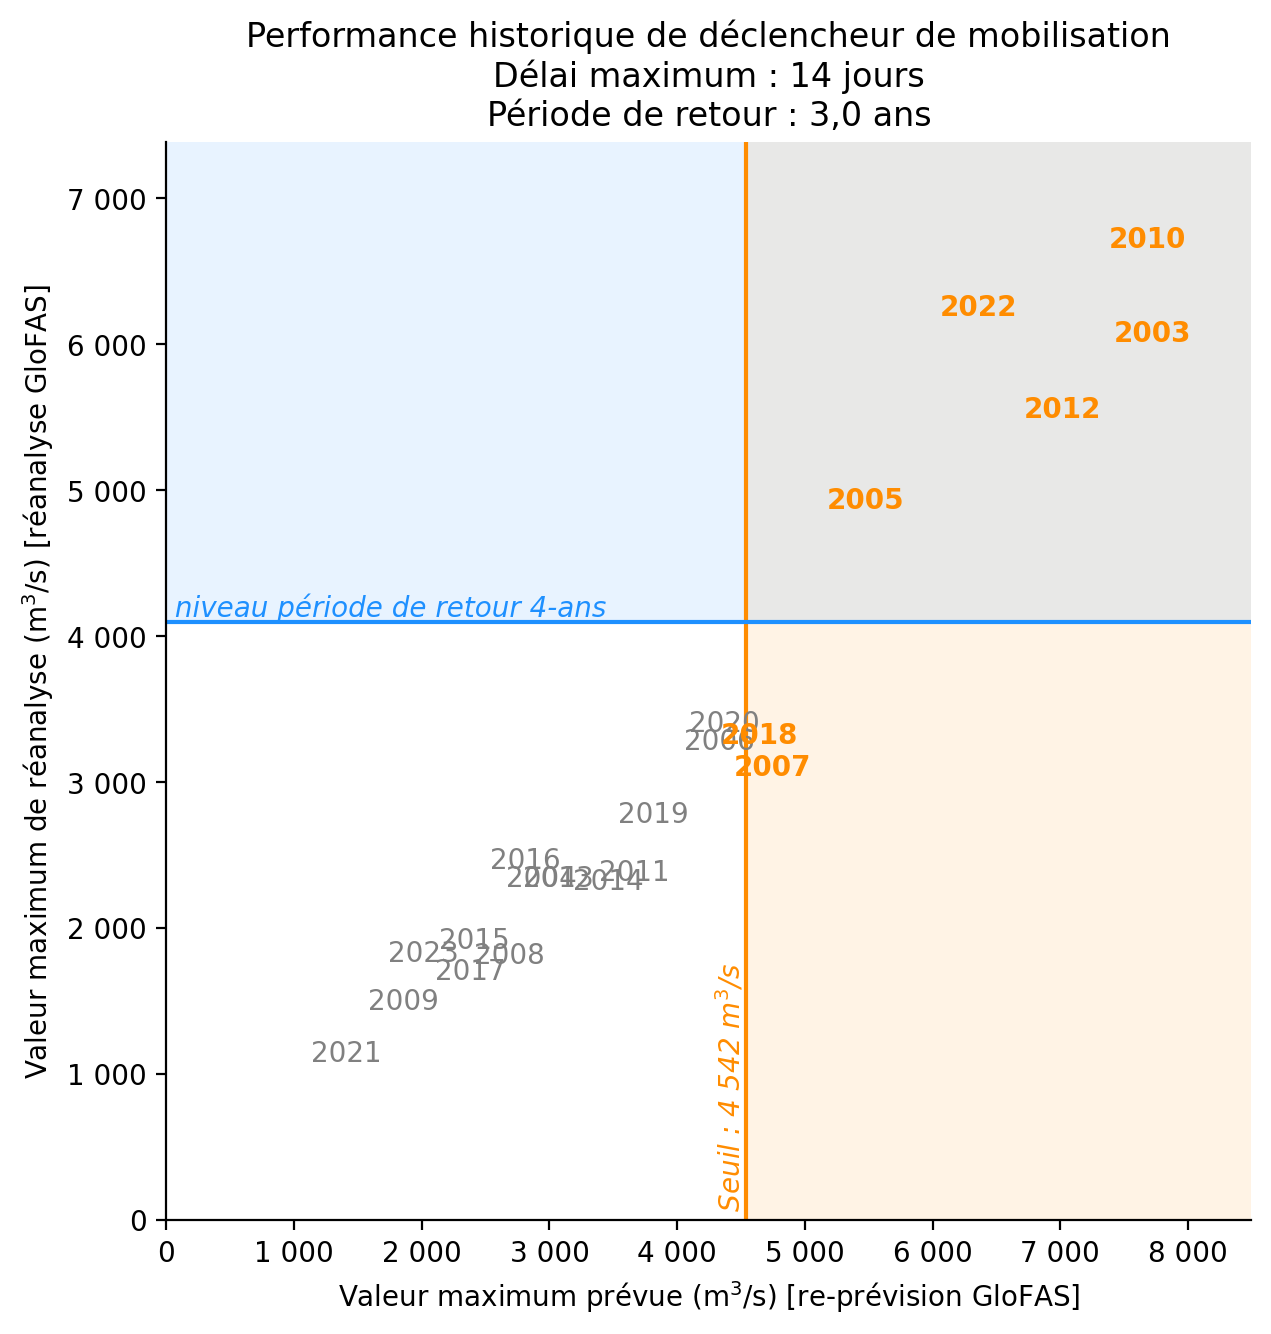

In [52]:
fig, ax = plot_trigger_years("readiness", lang="FR")

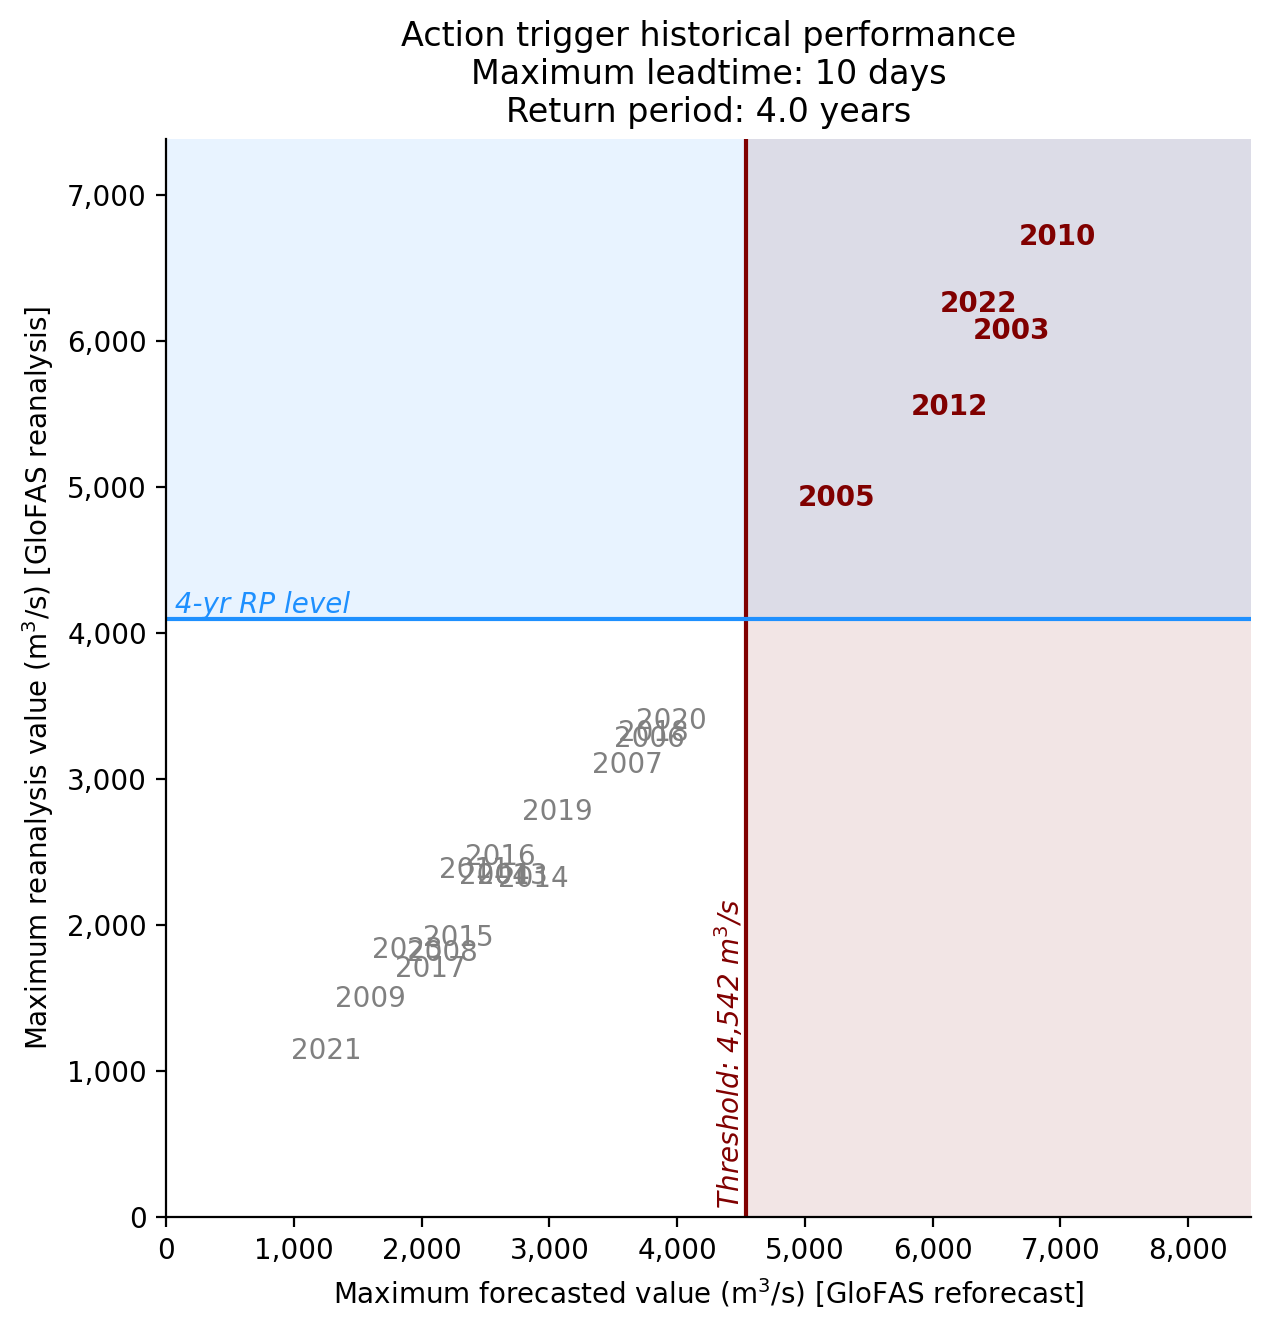

In [53]:
fig, ax = plot_trigger_years("action")

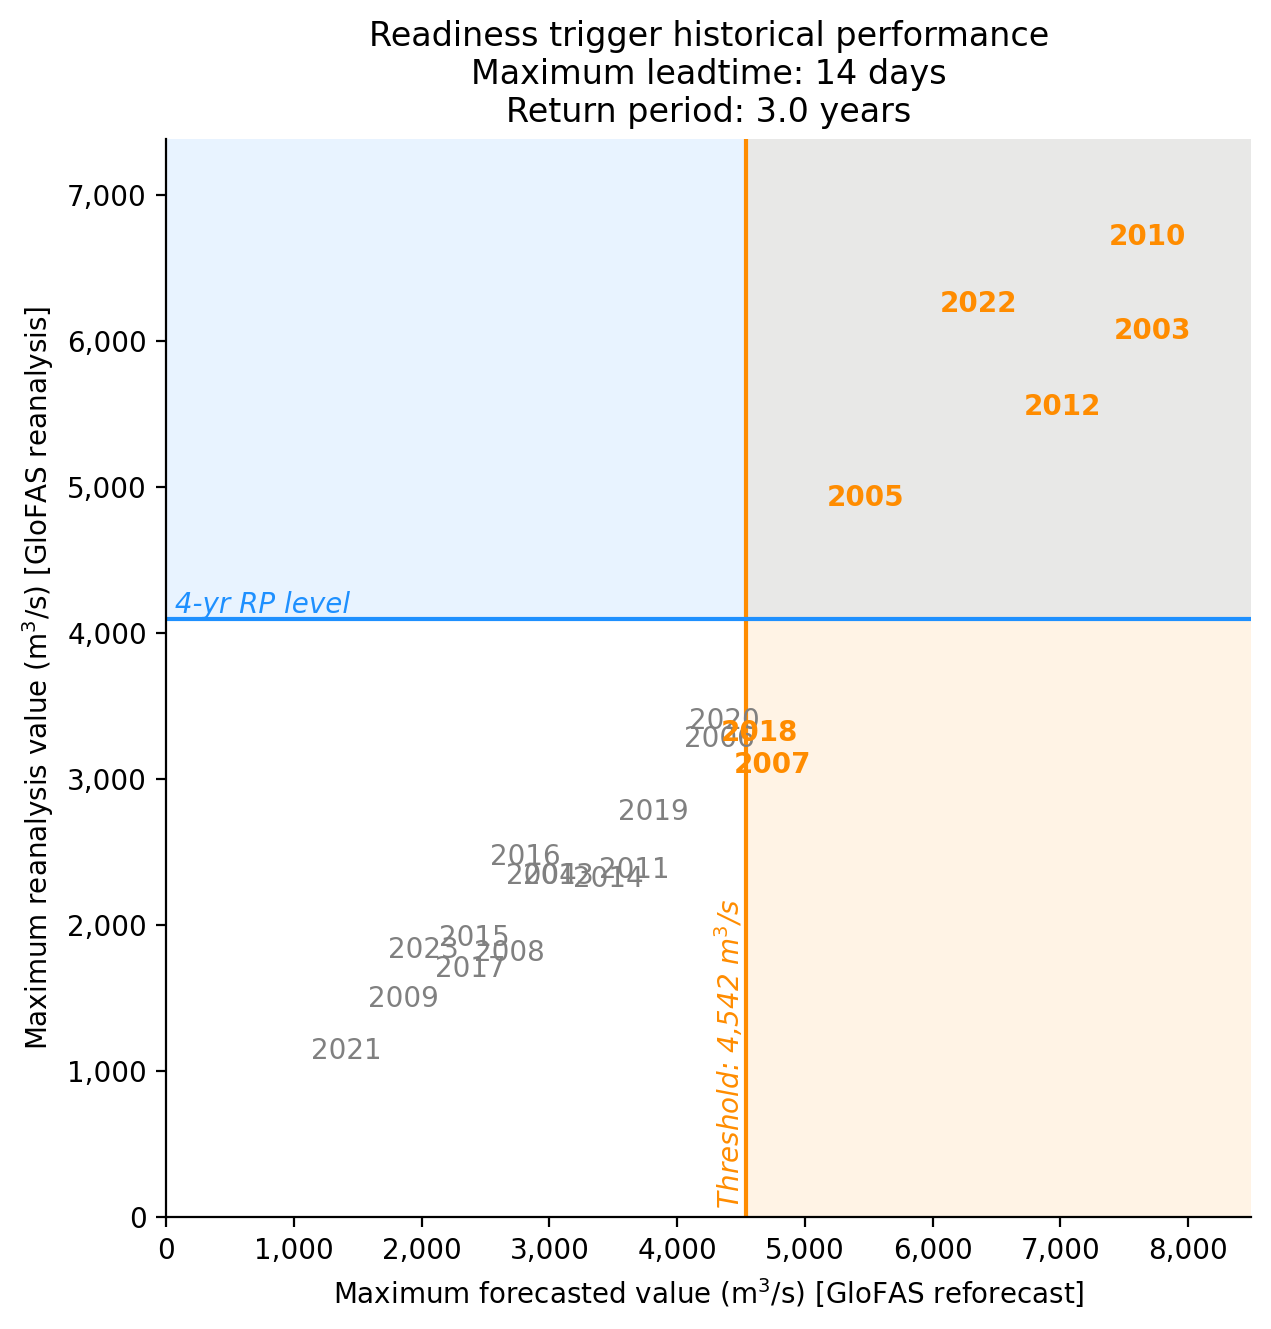

In [54]:
fig, ax = plot_trigger_years("readiness")